[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  1 of 1 completed


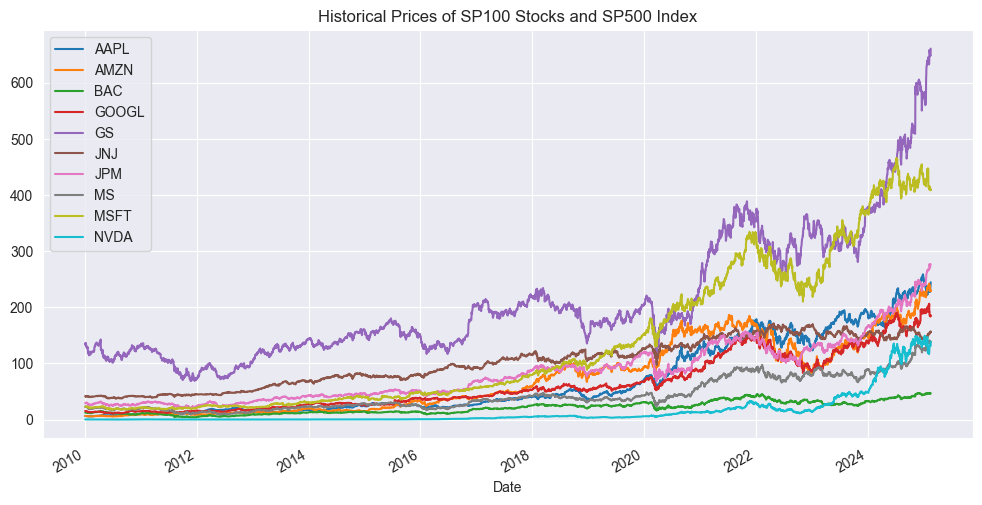

Best Sharpe Ratio:  1.0486193439579559
Portfolio Returns NaN: 0
Portfolio Cumulative Returns size: (251,)
Portfolio Last Cumulative Return: 1.638296071649057
Benchmark Returns NaN: 0
Benchmark Cumulative Returns size: (251,)
Benchmark Last Cumulative Return: 1.2615584111553533


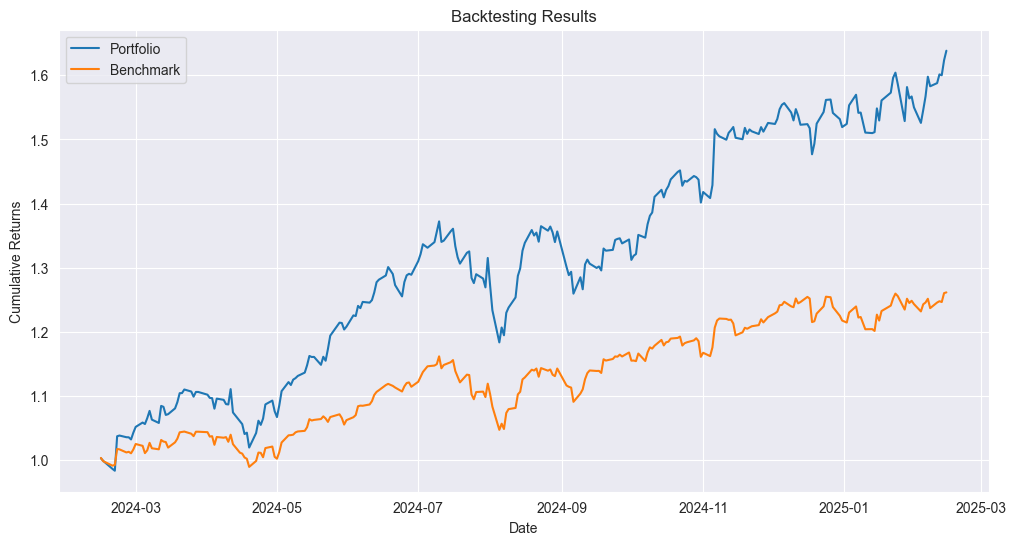

Portfolio Statistics:
---------------------
Mean Daily Return: 0.0021
Standard Deviation: 0.0138
Sharpe Ratio: 2.3812
Final Value: 1638.30
Benchmark Statistics:
---------------------
Mean Daily Return: 0.0010
Standard Deviation: 0.0089
Sharpe Ratio: 1.7298
Final Value: 1261.56


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta

# สต็อคที่ต้องการ
stocks = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'NVDA', 'JNJ', 'JPM', 'BAC', 'GS', 'MS']
start_date = '2010-01-01'

# ดาวน์โหลดข้อมูลราคาปิด (Close)
data = yf.download(stocks, start=start_date)['Close']
benchmark = yf.download('^OEX', start=start_date)['Close']

# Visualize the data
sns.set_style('darkgrid')
data.plot(figsize=(12, 6))
plt.title('Historical Prices of SP100 Stocks and SP500 Index')
plt.legend(loc='upper left')
plt.show()

# ฟังก์ชันการคำนวณ Sharpe Ratio สำหรับพอร์ต
def fitness_function(weights, data):
    data_returns = np.log(data) - np.log(data.shift(1))
    data_returns = data_returns.dropna()
    
    portfolio_returns = np.dot(data_returns, weights)
    portfolio_mean = np.mean(portfolio_returns)
    portfolio_std = np.std(portfolio_returns)
    sharpe_ratio = (portfolio_mean / portfolio_std) * np.sqrt(252)
    return sharpe_ratio

# ฟังก์ชัน Genetic Algorithm เพื่อหาพอร์ตโฟลิโอที่ดีที่สุด
def genetic_algorithm(data, population_size=200, num_generations=50, mutation_rate=0.05, elitism=0.1):
    # สร้างประชากรเริ่มต้น
    population = np.random.rand(population_size, len(data.columns))
    population = population / np.sum(population, axis=1)[:, np.newaxis]

    # คำนวณ Fitness สำหรับประชากรเริ่มต้น
    fitness = np.array([fitness_function(individual, data) for individual in population])
    
    for generation in range(num_generations):
        # จัดอันดับประชากรจาก Fitness ที่ดีที่สุด
        sorted_idx = np.argsort(fitness)[::-1]
        population = population[sorted_idx]
        fitness = fitness[sorted_idx]
        
        # คำนวณจำนวน Elites ที่จะนำมาจากประชากรเดิม
        num_elites = int(elitism * population_size)
        
        # สร้างลูกหลานจากประชากรที่เหลือ
        offspring = population[:num_elites]
        
        # เลือกพ่อแม่โดยใช้ Tournament Selection
        parent1_idx = np.random.randint(num_elites, population_size, size=population_size-num_elites)
        parent2_idx = np.random.randint(num_elites, population_size, size=population_size-num_elites)
        parent1 = population[parent1_idx]
        parent2 = population[parent2_idx]

        # การทำ Crossover และ Mutation
        crossover_prob = np.random.rand(population_size-num_elites, len(data.columns))
        crossover_mask = crossover_prob <= 0.5
        offspring_crossover = np.where(crossover_mask, parent1, parent2)

        mutation_prob = np.random.rand(population_size-num_elites, len(data.columns))
        mutation_mask = mutation_prob <= mutation_rate
        mutation_values = np.random.rand(population_size-num_elites, len(data.columns))
        mutation_direction = np.random.choice([-1, 1], size=(population_size-num_elites, len(data.columns)))
        offspring_mutation = np.where(mutation_mask, offspring_crossover + mutation_direction * mutation_values, offspring_crossover)

        # ตรวจสอบว่า population ใหม่มีน้ำหนักที่ถูกต้อง
        offspring_mutation = offspring_mutation / np.sum(offspring_mutation, axis=1)[:, np.newaxis]

        # รวม Elites กับลูกหลานในประชากรใหม่
        population = np.vstack((population[:num_elites], offspring_mutation))
        
        # คำนวณ Fitness ของประชากรใหม่
        fitness = np.array([fitness_function(individual, data) for individual in population])
        
    # คืนค่าค่าที่ดีที่สุดจากประชากรสุดท้าย
    best_idx = np.argmax(fitness)
    best_individual = population[best_idx]
    print('Best Sharpe Ratio: ', np.max(fitness)) 

    return best_individual

# ฟังก์ชันการทดสอบผลการลงทุน (Backtesting)
# ฟังก์ชันการทดสอบผลการลงทุน (Backtesting)
# ฟังก์ชันการทดสอบผลการลงทุน (Backtesting)
def backtest(genetic_algorithm, data, benchmark, initial_capital=1000):
    # แบ่งข้อมูลเป็น training และ testing
    train_data = data.iloc[:-252]
    test_data = data.iloc[-252:]

    # หา weights ของพอร์ตโฟลิโอจาก Genetic Algorithm
    weights = genetic_algorithm(data=train_data, population_size=100, num_generations=50, mutation_rate=0.01, elitism=0.01)

    # ตั้งค่า weights เป็น 0 หากค่าติดลบ
    weights[weights < 0] = 0

    # ปรับน้ำหนักให้รวมกันเป็น 1
    weights /= weights.sum()

    # คำนวณผลตอบแทนของพอร์ตโฟลิโอและ benchmark
    portfolio_returns = np.dot(test_data.pct_change().dropna(), weights)
    
    # แปลง portfolio_returns เป็น pandas.Series เพื่อใช้งาน isna()
    portfolio_returns = pd.Series(portfolio_returns)
    
    # ตรวจสอบว่า portfolio_returns ไม่มี NaN
    print(f"Portfolio Returns NaN: {portfolio_returns.isna().sum()}")
    
    portfolio_cum_returns = np.cumprod(1 + portfolio_returns)  # ใช้ np.cumprod
    print(f"Portfolio Cumulative Returns size: {portfolio_cum_returns.shape}")
    print(f"Portfolio Last Cumulative Return: {portfolio_cum_returns.iloc[-1]}")
    
    benchmark_returns = benchmark.iloc[-252:].pct_change().dropna()
    
    # แปลง benchmark_returns เป็น pandas.Series และทำให้เป็น 1D
    benchmark_returns = pd.Series(benchmark_returns.squeeze())
    
    print(f"Benchmark Returns NaN: {benchmark_returns.isna().sum()}")
    
    benchmark_cum_returns = np.cumprod(1 + benchmark_returns)  # ใช้ np.cumprod
    print(f"Benchmark Cumulative Returns size: {benchmark_cum_returns.shape}")
    print(f"Benchmark Last Cumulative Return: {benchmark_cum_returns.iloc[-1]}")
    
    portfolio_value = initial_capital * portfolio_cum_returns.iloc[-1] if portfolio_cum_returns.size > 0 else 0
    benchmark_value = initial_capital * benchmark_cum_returns.iloc[-1] if benchmark_cum_returns.size > 0 else 0

    # แสดงผลกราฟการทดสอบผล
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(benchmark_cum_returns.index, portfolio_cum_returns, label='Portfolio')
    ax.plot(benchmark_cum_returns, label='Benchmark')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Returns')
    ax.set_title('Backtesting Results')
    ax.legend()
    plt.show()

    # แสดงผลสถิติ
    print('Portfolio Statistics:')
    print('---------------------')
    print(f'Mean Daily Return: {np.mean(portfolio_returns):.4f}')
    print(f'Standard Deviation: {np.std(portfolio_returns):.4f}')
    print(f'Sharpe Ratio: {(np.mean(portfolio_returns) / np.std(portfolio_returns)) * np.sqrt(252):.4f}')
    print(f'Final Value: {portfolio_value:.2f}')
    print('Benchmark Statistics:')
    print('---------------------')
    print(f'Mean Daily Return: {np.mean(benchmark_returns):.4f}')
    print(f'Standard Deviation: {np.std(benchmark_returns):.4f}')
    print(f'Sharpe Ratio: {(np.mean(benchmark_returns) / np.std(benchmark_returns)) * np.sqrt(252):.4f}')
    print(f'Final Value: {benchmark_value:.2f}')
    return portfolio_returns, benchmark_returns, portfolio_cum_returns, benchmark_cum_returns



portfolio_returns, benchmark_returns, portfolio_cum_returns, benchmark_cum_returns = backtest(genetic_algorithm, data, benchmark)
